# Exploratory Data Analysis (EDA) — PubMedQA

## 1. Introduction

In this notebook, we perform Exploratory Data Analysis (EDA) on the PubMedQA dataset, a biomedical question answering dataset consisting of clinical questions, corresponding scientific abstracts, and labeled answers.

The primary objective of this analysis is to understand the structure, distribution, and characteristics of the dataset before building machine learning models for automatic medical question answering.

Specifically, we aim to:

- Examine the distribution of answer classes (yes, no, maybe)
- Analyze the length and complexity of questions and abstracts
- Identify patterns and imbalances in the dataset
- Gain insights that will guide feature representation and model selection

Understanding these aspects is essential for designing effective NLP pipelines, particularly in the biomedical domain where text is often complex and domain-specific.

This EDA will help motivate our later design choices, including the selection of text representations (e.g., TF-IDF vs contextual embeddings) and modeling approaches (e.g., classical ML vs transformer-based models).

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns

In [14]:
train_df = pd.read_parquet("train.parquet")
val_df = pd.read_parquet("val.parquet")
test_df = pd.read_parquet("test.parquet")
data = pd.read_parquet("data.parquet")

In [6]:
train_df["final_decision"].value_counts()

final_decision
yes      442
no       270
maybe     88
Name: count, dtype: int64

In [13]:
test_df["final_decision"].value_counts()

final_decision
yes      55
no       34
maybe    11
Name: count, dtype: int64

In [8]:
val_df["final_decision"].value_counts()

final_decision
yes      55
no       34
maybe    11
Name: count, dtype: int64

In [17]:
ser = data["final_decision"].value_counts()

## Distribution of PubMedQA Labels

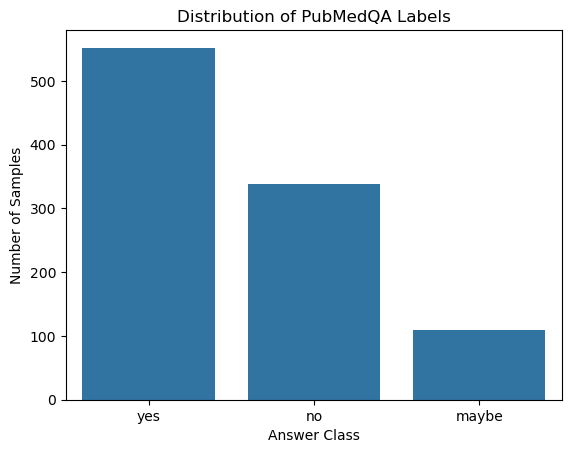

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x=ser.index,
    y=ser.values
)

plt.title("Distribution of PubMedQA Labels")
plt.xlabel("Answer Class")
plt.ylabel("Number of Samples")

plt.show()

## Question Length Distribution

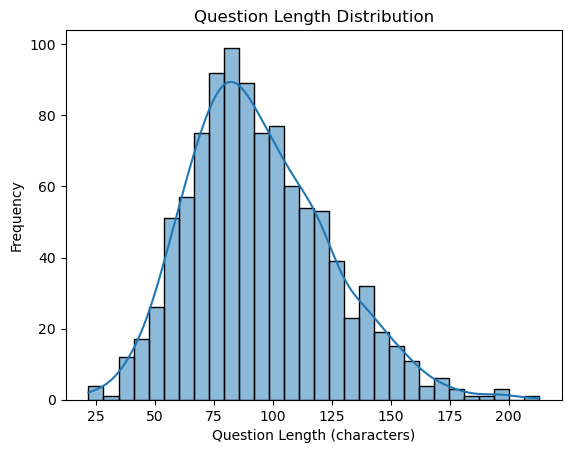

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

question_lengths = data["question"].apply(len)

sns.histplot(question_lengths, bins=30, kde=True)

plt.title("Question Length Distribution")
plt.xlabel("Question Length (characters)")
plt.ylabel("Frequency")

plt.show()


## Combined Context Length Distribution

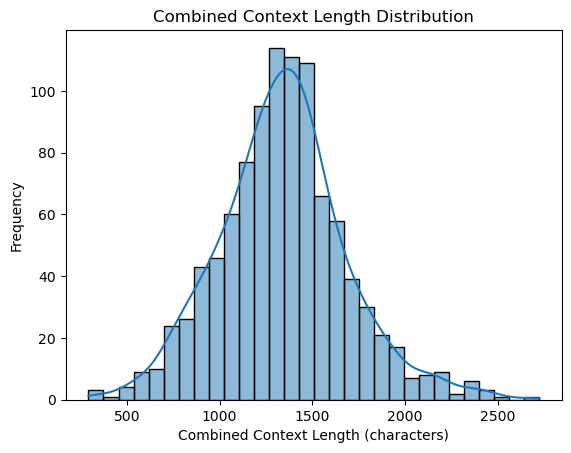

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

question_lengths = data["combined_context"].apply(len)

sns.histplot(question_lengths, bins=30, kde=True)

plt.title("Combined Context Length Distribution")
plt.xlabel("Combined Context Length (characters)")
plt.ylabel("Frequency")

plt.show()

In [36]:
yes_question_len = data[data["final_decision"] == "yes"]["question"].apply(len)
no_question_len = data[data["final_decision"] == "no"]["question"].apply(len)
may_be_question_len = data[data["final_decision"] == "maybe"]["question"].apply(len)

## Question Length by Answer Class

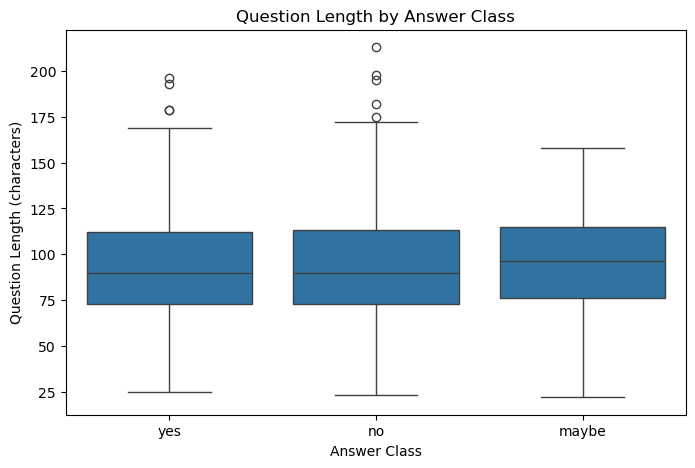

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a question length column
data["question_length"] = data["question"].apply(len)

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="final_decision",
    y="question_length",
    data=data
)

plt.title("Question Length by Answer Class")
plt.xlabel("Answer Class")
plt.ylabel("Question Length (characters)")

plt.show()

## Context Length by Answer Class

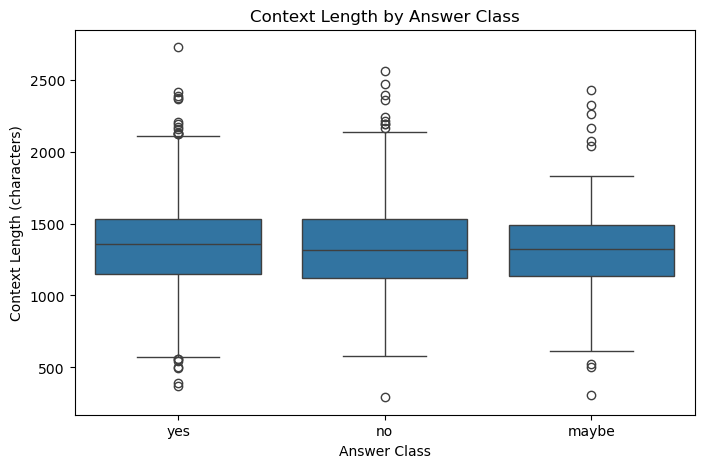

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
``
# Create a question length column
data["len_combined_context"] = data["combined_context"].apply(len)

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="final_decision",
    y="len_combined_context",
    data=data
)

plt.title("Context Length by Answer Class")
plt.xlabel("Answer Class")
plt.ylabel("Context Length (characters)")

plt.show()

## Word Cloud of PubMedQA Questions

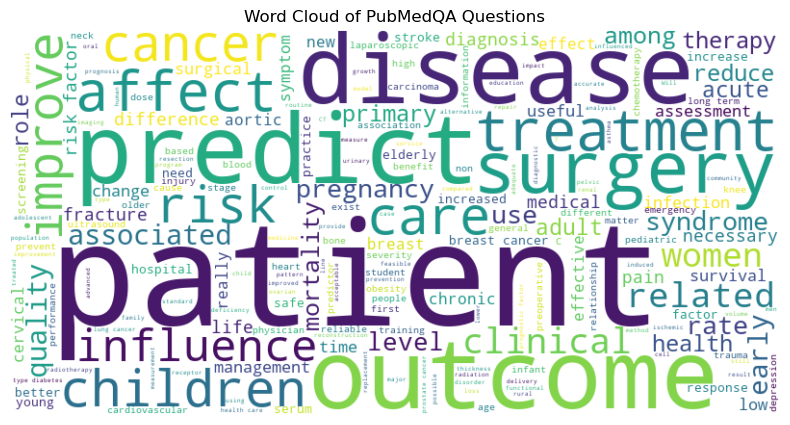

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(data["question"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of PubMedQA Questions")

plt.show()